## Similarity fn qualitative comparison

In [1]:
import os
#virtually move to parent directory
os.chdir("..")

import torch
import matplotlib
from matplotlib import pyplot as plt

import utils
import data_utils
import similarity
from experiments import text_colorings

/home/s4yadav/private/workspace/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [2]:
figure = 'fig14b'

settings = {'fig14a': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": [46, 10, 242, 206]}, 
            'fig14b': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": [1203, 1731, 683, 185]},
           }

target_name = settings[figure]["target_name"]
target_layer = settings[figure]["target_layer"]
neurons_to_display = settings[figure]["neurons_to_display"]

clip_name = 'ViT-B/16'
d_probe = 'imagenet_broden'
concept_set = 'data/20k.txt'
batch_size = 200
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'


## Run CLIP-Dissect

In [3]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /tmp/xdg-cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 291MB/s]


In [4]:
similarity_fn = similarity.cos_similarity
similarities_cos, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity.cos_similarity, device=device)

similarities_soft_wpmi, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity.soft_wpmi, device=device)

/home/s4yadav/private/workspace/CLIP-dissect/utils.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_features = torch.load(clip_save_name, map_location='cpu').floa

torch.Size([2048, 20000])


## Visualize

In [5]:
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

get_color = text_colorings.get_coloring(figure)

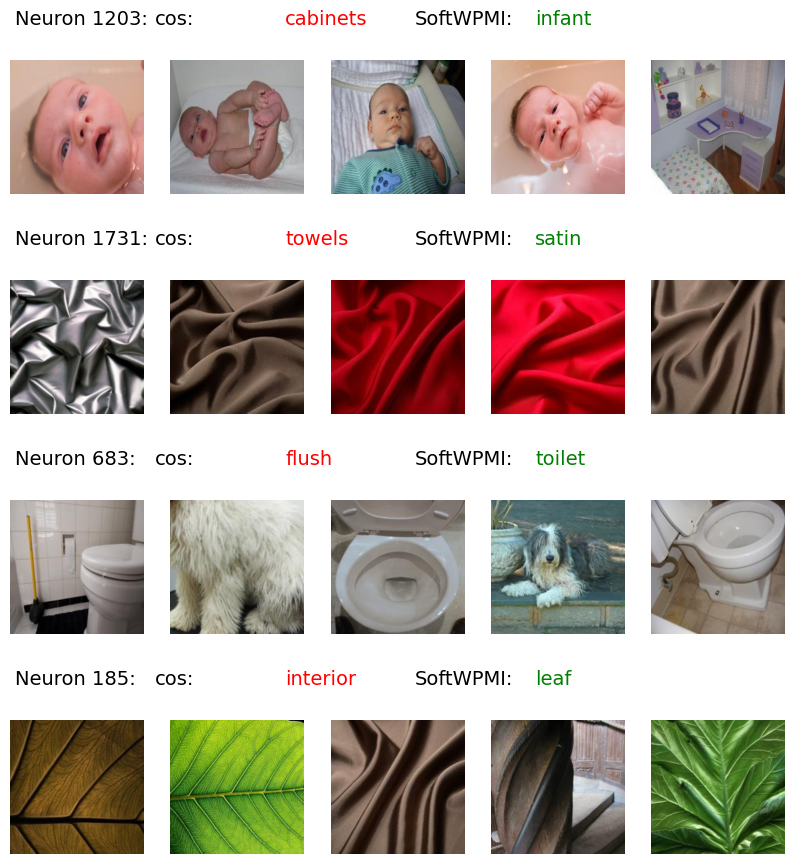

In [6]:
# Calculate which neurons to show
if type(neurons_to_display)==list:
    ids_to_check = neurons_to_display
if neurons_to_display == "CLIP-Dissect":
    ids_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
elif neurons_to_display == "NetDissect":
    ids_to_check = torch.sort(torch.tensor(nd_ious), descending=True)[1][:10]

    
#plot figures
font_size=14
font = {'size' : font_size}
matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(ids_to_check)*2.2])
subfigs = fig.subfigures(nrows=len(ids_to_check), ncols=1)
for j, orig_id in enumerate(ids_to_check):
    _, cos_ids = torch.topk(similarities_cos[orig_id], k=5, largest=True)
    _, soft_wpmi_ids = torch.topk(similarities_soft_wpmi[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "cos:", size=font_size)
    subfig.text(0.4, 0.96, words[int(cos_ids[0])], size=font_size, color=get_color("cos", j))
    subfig.text(0.53 ,0.96, "SoftWPMI:", size=font_size)
    subfig.text(0.65 ,0.96, words[int(soft_wpmi_ids[0])], size=font_size, color=get_color("soft_wpmi", j))
    
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
    #fig.tight_layout()
plt.show()